In [1]:
import os
import pandas as pd

path_this = os.path.dirname(os.path.abspath(__name__))
path_root = os.path.join(path_this, '..')
path_dataset = os.path.join(path_root, 'data')

In [2]:
df_dataset = pd.read_csv(os.path.join(path_dataset,'preprocessed_dataset.csv'))
demograph_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
services_features = [
	'PhoneService', 'MultipleLines', 'InternetService', 
	'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
	'TechSupport', 'StreamingTV', 'StreamingMovies']
membership_features = [
	'Contract', 'PaperlessBilling', 'PaymentMethod', 
	'MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']

print("Customer Demography")
display(df_dataset.loc[
	:, ['customerID'] + demograph_features + ['Churn']].sample(5, random_state=42))
print("Service")
display(df_dataset.loc[
	:, ['customerID'] + services_features + ['Churn']].sample(5, random_state=42))
print("Membership")
display(df_dataset.loc[
	:, ['customerID'] + membership_features].sample(5, random_state=42))

Customer Demography


,customerID,gender,SeniorCitizen,Partner,Dependents,Churn
2476,6614-ywysc,male,yes,yes,no,0
6773,9546-kdtrb,female,no,no,no,0
6116,0871-uruwo,male,no,yes,no,1
3047,5151-hqrdg,male,no,yes,no,0
4092,6624-jdrds,female,no,no,no,0


Service


,customerID,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Churn
2476,6614-ywysc,yes,yes,no,no internet service,no internet service,no internet service,no internet service,no internet service,no internet service,0
6773,9546-kdtrb,yes,yes,no,no internet service,no internet service,no internet service,no internet service,no internet service,no internet service,0
6116,0871-uruwo,yes,yes,fiber optic,no,no,yes,no,yes,yes,1
3047,5151-hqrdg,yes,yes,dsl,yes,no,no,no,no,no,0
4092,6624-jdrds,no,no phone service,dsl,yes,no,no,no,no,no,0


Membership


,customerID,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure,Churn
2476,6614-ywysc,two year,no,bank transfer (automatic),25.00,1501.75,61,0
6773,9546-kdtrb,month-to-month,no,bank transfer (automatic),24.70,465.85,19,0
6116,0871-uruwo,month-to-month,yes,credit card (automatic),102.25,1359.00,13,1
3047,5151-hqrdg,month-to-month,yes,mailed check,55.05,2030.75,37,0
4092,6624-jdrds,month-to-month,no,bank transfer (automatic),29.45,161.45,6,0


In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from copy import deepcopy

In [7]:
TARGET_COL = 'Churn'
# drop unnecessary columns
X = df_dataset.drop(columns=[TARGET_COL, 'customerID', 'TotalCharges'])
y = df_dataset[TARGET_COL]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, stratify=y, random_state=42)

In [15]:
# TARGET = 'Churn'
# X = df_xgboost.drop(columns=[
# 	TARGET, 'customerID', 'gender', 'SeniorCitizen', 
# 	'Partner', 'Dependents', 'TotalCharges', 'PaperlessBilling',
# 	'PaymentMethod'])
# y = df_xgboost[TARGET]
y.value_counts(dropna=False, normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [10]:
numerical_features = X.select_dtypes(exclude='object').columns.to_list()
categorical_features = X.select_dtypes(include='object').columns.to_list()
print(numerical_features)
print(categorical_features)

['tenure', 'MonthlyCharges']
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [16]:
preprocessor = ColumnTransformer([
	('num', 'passthrough', numerical_features),
	('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
])

In [17]:
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

In [18]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train_enc, label=y_train)
dtest  = xgb.DMatrix(X_test_enc, label=y_test)


In [24]:
# pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 4,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": pos_weight,
    "seed": 42
}


In [25]:
evals = [(dtrain, "train"), (dtest, "valid")]

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=500,
    evals=evals,
    early_stopping_rounds=30,
    verbose_eval=False
)


In [26]:
y_prob = model.predict(dtest)
y_pred = (y_prob >= 0.5).astype(int)


In [27]:
from sklearn.metrics import classification_report, log_loss, roc_auc_score

print(classification_report(y_test, y_pred))
print("Log Loss:", log_loss(y_test, y_prob))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

Log Loss: 0.4970317994608935
ROC AUC: 0.8377007935973826


# Cross Validation

In [28]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
import numpy as np
import xgboost as xgb

cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=X)
    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=preprocessor.get_feature_names_out())
    dval   = xgb.DMatrix(X_val, label=y_val)

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=500,
        evals=[(dval, "val")],
        early_stopping_rounds=30,
        verbose_eval=False
    )

    cv_scores.append(model.best_score)


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:gender: object, SeniorCitizen: object, Partner: object, Dependents: object, PhoneService: object, MultipleLines: object, InternetService: object, OnlineSecurity: object, OnlineBackup: object, DeviceProtection: object, TechSupport: object, StreamingTV: object, StreamingMovies: object, Contract: object, PaperlessBilling: object, PaymentMethod: object

In [48]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
	break

In [50]:
train_idx, val_idx

(array([   0,    1,    3, ..., 7028, 7029, 7030], shape=(5625,)),
 array([   2,   10,   18, ..., 7020, 7027, 7031], shape=(1407,)))

In [53]:
X.shape

(7032, 14)

---

# REVISI CODING

In [30]:
numerical_features = X.select_dtypes(exclude='object').columns.to_list()
categorical_features = X.select_dtypes(include='object').columns.to_list()

In [31]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [32]:
xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score, f1_score,
    log_loss
)

In [34]:
cv_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
	print(f'\n--- Fold {fold} ---')

	# split (IMPORTANT: iloc)
	X_tr = X.iloc[train_idx]
	X_val = X.iloc[val_idx]
	y_tr = y.iloc[train_idx]
	y_val = y.iloc[val_idx]

	# preprocessing (fit ONLY on train)
	preprocessor = ColumnTransformer(
		transformers=[
			('num', 'passthrough', numerical_features),
			('cat', OneHotEncoder(handle_unknown='ignore',drop='first'), categorical_features)
		]
	)

	X_tr_enc = preprocessor.fit_transform(X_tr)
	X_val_enc = preprocessor.transform(X_val)

	# DMatrix
	dtrain = xgb.DMatrix(X_tr_enc, label=y_tr)
	dval = xgb.DMatrix(X_val_enc, label=y_val)

	# train
	model = xgb.train(
		params=xgb_params,
		dtrain=dtrain,
		num_boost_round=500,
		evals=[(dval, 'validation')],
		early_stopping_rounds=30,
		verbose_eval=False
	)

	# prediction
	y_val_proba = model.predict(dval)
	thresholds = np.linspace(0.1, 0.5, 50)
	
	# find better threshold
	best_f1 = 0
	best_t = 0

	for t in thresholds:
		y_pred_t = (y_val_proba >= t).astype(int)
		f1 = f1_score(y_val, y_pred_t)

		if f1 > best_f1:
			best_f1 = f1
			best_t = t

	best_f1
	# get better threshold
	y_val_pred = (y_val_proba >= best_t).astype(int)

	# metrics
	fold_metrics = {
		'fold': fold,
		'logloss': log_loss(y_val, y_val_proba),
		'accuracy': accuracy_score(y_val, y_val_pred),
		'precision': precision_score(y_val, y_val_pred),
		'recall': recall_score(y_val, y_val_pred),
		'f1-score': f1_score(y_val, y_val_pred),
		'roc_auc': roc_auc_score(y_val, y_val_proba),
		'best_iteration': model.best_iteration,
		'best_t': best_t,
		'best_f1': best_f1
	}

	cv_results.append(fold_metrics)



--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---


In [35]:
cv_df = pd.DataFrame(cv_results)

print("\n===== CV PERFORMANCE =====")
print(cv_df.mean(numeric_only=True))
print("\nStd Dev:")
print(cv_df.std(numeric_only=True))



===== CV PERFORMANCE =====
fold               3.000000
logloss            0.412489
accuracy           0.784553
precision          0.576628
recall             0.734107
f1-score           0.644257
roc_auc            0.848578
best_iteration    99.600000
best_t             0.336735
best_f1            0.644257
dtype: float64

Std Dev:
fold               1.581139
logloss            0.005774
accuracy           0.013937
precision          0.029433
recall             0.047748
f1-score           0.007351
roc_auc            0.005041
best_iteration    19.282116
best_t             0.043580
best_f1            0.007351
dtype: float64


In [36]:
cv_df

,fold,logloss,accuracy,precision,recall,f1-score,roc_auc,best_iteration,best_t,best_f1
0,1,0.411977,0.803838,0.617225,0.689840,0.651515,0.848884,71,0.377551,0.651515
1,2,0.403960,0.786780,0.576763,0.743316,0.649533,0.856045,121,0.328571,0.649533
2,3,0.413238,0.770982,0.548023,0.780161,0.643805,0.847905,110,0.304082,0.643805
3,4,0.413069,0.770982,0.549057,0.778075,0.643805,0.848201,91,0.287755,0.643805
4,5,0.420201,0.790185,0.592075,0.679144,0.632628,0.841853,105,0.385714,0.632628


In [37]:
importance = model.get_score(importance_type="gain")

feature_names = preprocessor.get_feature_names_out()
feature_names


array(['num__tenure', 'num__MonthlyCharges', 'cat__gender_male',
       'cat__SeniorCitizen_yes', 'cat__Partner_yes',
       'cat__Dependents_yes', 'cat__PhoneService_yes',
       'cat__MultipleLines_no phone service', 'cat__MultipleLines_yes',
       'cat__InternetService_fiber optic', 'cat__InternetService_no',
       'cat__OnlineSecurity_no internet service',
       'cat__OnlineSecurity_yes', 'cat__OnlineBackup_no internet service',
       'cat__OnlineBackup_yes',
       'cat__DeviceProtection_no internet service',
       'cat__DeviceProtection_yes',
       'cat__TechSupport_no internet service', 'cat__TechSupport_yes',
       'cat__StreamingTV_no internet service', 'cat__StreamingTV_yes',
       'cat__StreamingMovies_no internet service',
       'cat__StreamingMovies_yes', 'cat__Contract_one year',
       'cat__Contract_two year', 'cat__PaperlessBilling_yes',
       'cat__PaymentMethod_credit card (automatic)',
       'cat__PaymentMethod_electronic check',
       'cat__PaymentMetho

In [38]:
# len(importance.values())
len(feature_names)

29

In [39]:
importance_df = pd.DataFrame({
	'feature': feature_names,
	'gain': [
		importance.get(f"f{i}", 0.0)
		for i in range(len(feature_names))
	]
})
print(importance_df.shape)
importance_df.sort_values(by='gain', ascending=False)

(29, 2)


,feature,gain
15,cat__DeviceProtection_no internet service,79.878784
24,cat__Contract_two year,63.700611
9,cat__InternetService_fiber optic,47.236572
23,cat__Contract_one year,42.289509
11,cat__OnlineSecurity_no internet service,30.826092
27,cat__PaymentMethod_electronic check,19.372839
10,cat__InternetService_no,15.689191
0,num__tenure,12.752413
18,cat__TechSupport_yes,7.846728
12,cat__OnlineSecurity_yes,6.910719


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='gain', ylabel='feature'>

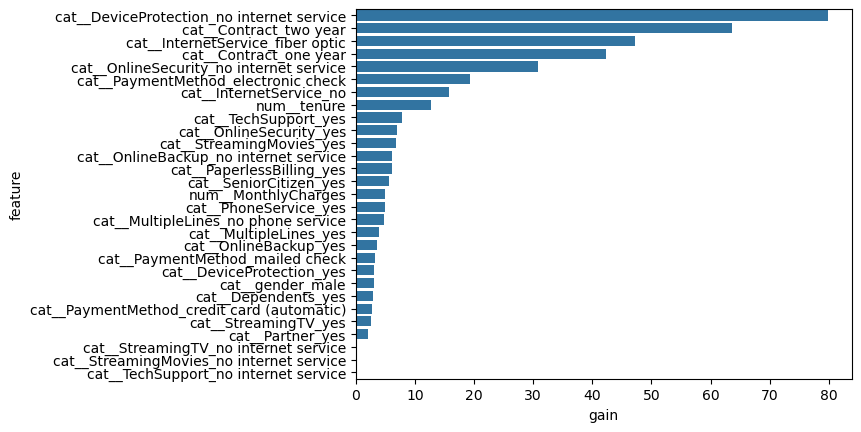

In [41]:
sns.barplot(importance_df.sort_values(by='gain', ascending=False), x='gain', y='feature')

In [42]:
import shap
import matplotlib.pyplot as plt


In [43]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_tr_enc)
shap_values


array([[ 1.29853165e+00, -2.10937902e-01,  7.74412928e-03, ...,
         1.52770542e-02,  2.42838606e-01,  2.26355530e-02],
       [-4.82984334e-01, -1.38395354e-01,  2.22283565e-02, ...,
        -9.72570328e-04, -1.66801959e-01, -8.91556889e-02],
       [ 9.07028317e-01, -1.18600786e-01,  7.82570895e-03, ...,
         5.06641064e-03, -1.50787115e-01, -6.50882497e-02],
       ...,
       [ 5.72297312e-02, -2.53829867e-01, -6.26491988e-03, ...,
         1.26485405e-02,  2.79446661e-01,  3.05748824e-02],
       [ 6.55513167e-01, -8.40060189e-02,  1.62477326e-03, ...,
         1.46511057e-02, -1.23777188e-01, -4.33826409e-02],
       [-6.19245350e-01,  5.99149585e-01,  7.87448958e-02, ...,
         5.57499751e-03, -1.13819107e-01,  1.47477817e-02]],
      shape=(5626, 29), dtype=float32)

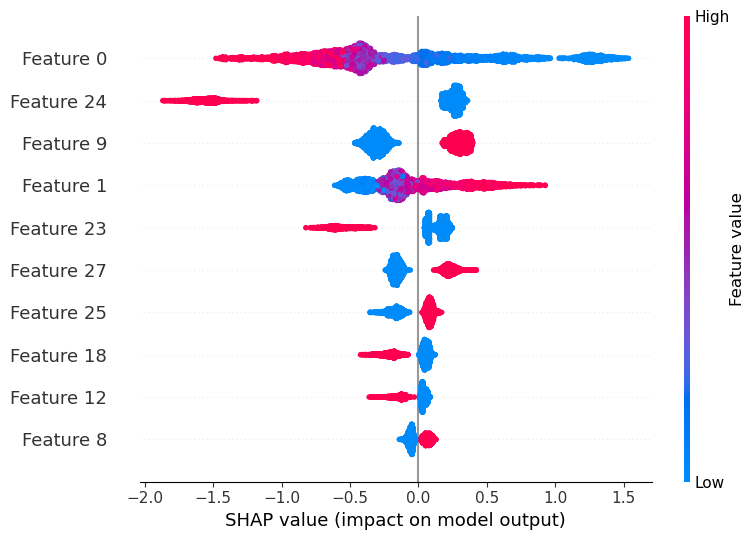

In [44]:
shap.summary_plot(
    shap_values,
    X_tr_enc,
    plot_type="dot",
    max_display=10
)


In [45]:
# shap_values = explainer.shap_values(X_train)
model.feature_names = X_train.columns.to_list()

In [46]:
model.feature_names 

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges']